# ONDOUSDC Short-Horizon Feature Comparison

This is the canonical `04` notebook for the ONDOUSDC short-horizon study.
It keeps the scope narrow and compares four features on one consistent train / validation / stress split, with no extra regime filtering in the main tables.


## Feature Definitions And Scope

This notebook compares four features only:

- `top_imbalance`: top-of-book size skew
- `trade_flow_imbalance`: signed trade pressure over the last `T=10` trades
- `impact_pressure_raw`: signed flow normalized by the opposite side of the top of book
- `impact_pressure_log`: signed log compression of `impact_pressure_raw`

Definitions:

- `top_imbalance = (bid1_qty - ask1_qty) / (bid1_qty + ask1_qty)`
- `trade_flow_imbalance = build_imbalance_for_signal(trade_frame, signal_T=10, a=0.0)`
- `impact_pressure_raw = trade_flow_imbalance / ask1_qty` when flow is non-negative, otherwise `trade_flow_imbalance / bid1_qty`
- `impact_pressure_log = sign(impact_pressure_raw) * log1p(abs(impact_pressure_raw))`

Split used everywhere:

- train: `20260226`, `20260227`
- validation: `20260228`
- stress: `20260301`

Horizons used everywhere:

- `1s`
- `2s`
- `3s`


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.api as sm


def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / 'notebooks' / 'notebook_utils.py'
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location('notebook_utils', utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f'Could not load notebook utilities from {utils_path}')
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError('Could not locate notebooks/notebook_utils.py')


notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()

from stats.features import make_trade_frame
from stats.microprice import resolve_tick_size
from stats.notebook import load_orderflow_day

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

PROJECT_ROOT = /Users/hoangdeveloper/PycharmProjects/exchange-data-backtester


In [2]:
EXCHANGE = 'binance'
SYMBOL = 'ONDOUSDC'
DAYS = ['20260226', '20260227', '20260228', '20260301']
TRAIN_DAYS = ['20260226', '20260227']
VALID_DAY = '20260228'
STRESS_DAY = '20260301'
HORIZONS = ['1s', '2s', '3s']
FLOW_SIGNAL_T = 10
FLOW_A = 0.0
EPS = 1e-9
REPLAY_ON_GAP = 'skip-segment'

In [3]:
FEATURE_SPECS = [
    ('top_imbalance', 'top'),
    ('trade_flow_imbalance', 'flow'),
    ('impact_pressure_raw', 'impact_pressure_raw'),
    ('impact_pressure_log', 'impact_pressure_log'),
]

COMBINED_SPECS = [
    ('flow+top', ['trade_flow_imbalance', 'top_imbalance']),
    ('flow+impact_pressure_raw', ['trade_flow_imbalance', 'impact_pressure_raw']),
    ('flow+impact_pressure_log', ['trade_flow_imbalance', 'impact_pressure_log']),
    ('top+impact_pressure_raw', ['top_imbalance', 'impact_pressure_raw']),
    ('top+impact_pressure_log', ['top_imbalance', 'impact_pressure_log']),
    ('flow+top+impact_pressure_raw', ['trade_flow_imbalance', 'top_imbalance', 'impact_pressure_raw']),
    ('flow+top+impact_pressure_log', ['trade_flow_imbalance', 'top_imbalance', 'impact_pressure_log']),
]


def build_feature_frame(trade_frame: pd.DataFrame, book_state: pd.DataFrame, horizon: str) -> pd.DataFrame:
    trade_frame = trade_frame.sort_values('ts').reset_index(drop=True).copy()
    book_state = book_state.sort_values('ts').reset_index(drop=True).copy()
    book_mid_frame = book_state[['ts', 'log_mid']].copy()

    flow = notebook_utils.build_imbalance_for_signal(trade_frame, signal_T=FLOW_SIGNAL_T, a=FLOW_A)
    frame = trade_frame[['ts']].copy()
    frame['trade_flow_imbalance'] = flow
    frame = pd.merge_asof(
        frame.sort_values('ts'),
        book_state[['ts', 'bid1_qty', 'ask1_qty', 'top_imbalance', 'mid', 'spread', 'spread_ticks']].sort_values('ts'),
        on='ts',
        direction='backward',
    )
    frame['impact_pressure_raw'] = np.where(
        frame['trade_flow_imbalance'] >= 0,
        frame['trade_flow_imbalance'] / (frame['ask1_qty'] + EPS),
        frame['trade_flow_imbalance'] / (frame['bid1_qty'] + EPS),
    )
    frame['impact_pressure_log'] = np.sign(frame['impact_pressure_raw']) * np.log1p(np.abs(frame['impact_pressure_raw']))
    frame['future_return'] = notebook_utils.build_clock_time_delta(trade_frame, book_mid_frame, horizon)
    frame['horizon'] = horizon
    return frame.dropna(subset=['future_return']).reset_index(drop=True)


def summarize_feature(frame: pd.DataFrame, feature_col: str) -> pd.Series:
    sub = frame[[feature_col, 'future_return']].dropna().copy()
    x = sub[feature_col].to_numpy(dtype=float)
    y = sub['future_return'].to_numpy(dtype=float)
    if len(sub) == 0:
        return pd.Series({'n': 0, 'mean_return_bps': np.nan, 'pearson': np.nan, 'spearman': np.nan, 'sign_hit_rate': np.nan})
    pearson = float(np.corrcoef(x, y)[0, 1]) if len(sub) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    spearman = float(np.corrcoef(pd.Series(x).rank(method='average'), pd.Series(y).rank(method='average'))[0, 1]) if len(sub) > 1 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    sign_hit = float(np.mean(np.sign(x) == np.sign(y))) if len(sub) else np.nan
    return pd.Series({
        'n': int(len(sub)),
        'mean_return_bps': float(np.mean(y) * 1e4),
        'pearson': pearson,
        'spearman': spearman,
        'sign_hit_rate': sign_hit,
    })


def fit_ols_beta(frame: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    sub = frame[['future_return', *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    y = sub['future_return'].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    return beta


def ols_predict(frame: pd.DataFrame, feature_cols: list[str], beta: np.ndarray) -> tuple[pd.DataFrame, np.ndarray]:
    sub = frame[['future_return', *feature_cols]].dropna().copy()
    x = np.column_stack([np.ones(len(sub), dtype=float), sub[feature_cols].to_numpy(dtype=float)])
    pred = x @ beta
    return sub, pred


def ols_metrics(y_true: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(y_true) & np.isfinite(pred)
    if not mask.any():
        return {'n': 0, 'r2': np.nan, 'pearson': np.nan, 'spearman': np.nan, 'hit_rate': np.nan}
    y = y_true[mask]
    p = pred[mask]
    if len(y) > 1 and np.std(y) > 0 and np.std(p) > 0:
        pearson = float(np.corrcoef(y, p)[0, 1])
        spearman = float(np.corrcoef(pd.Series(y).rank(method='average'), pd.Series(p).rank(method='average'))[0, 1])
        r2 = float(1.0 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2))
    else:
        pearson = np.nan
        spearman = np.nan
        r2 = np.nan
    return {
        'n': int(len(y)),
        'r2': r2,
        'pearson': pearson,
        'spearman': spearman,
        'hit_rate': float(np.mean(np.sign(p) == np.sign(y))),
    }


def roc_auc_from_scores(y_true: np.ndarray, scores: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    pos = y_true == 1
    neg = y_true == 0
    n_pos = int(pos.sum())
    n_neg = int(neg.sum())
    if n_pos == 0 or n_neg == 0:
        return np.nan
    ranks = pd.Series(scores).rank(method='average').to_numpy(dtype=float)
    sum_pos = float(ranks[pos].sum())
    return (sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)


def binary_metrics(y_true: np.ndarray, prob: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=int)
    prob = np.asarray(prob, dtype=float)
    pred = (prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    acc = float((pred == y_true).mean()) if len(y_true) else np.nan
    precision = float(tp / (tp + fp)) if (tp + fp) else np.nan
    recall = float(tp / (tp + fn)) if (tp + fn) else np.nan
    specificity = float(tn / (tn + fp)) if (tn + fp) else np.nan
    brier = float(np.mean((prob - y_true) ** 2)) if len(y_true) else np.nan
    clipped = np.clip(prob, 1e-12, 1 - 1e-12)
    log_loss = float(-np.mean(y_true * np.log(clipped) + (1 - y_true) * np.log(1 - clipped))) if len(y_true) else np.nan
    auc = roc_auc_from_scores(y_true, prob)
    return {
        'n': int(len(y_true)),
        'pos_rate': float(y_true.mean()) if len(y_true) else np.nan,
        'pred_pos_rate': float(pred.mean()) if len(pred) else np.nan,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'auc': auc,
        'brier': brier,
        'log_loss': log_loss,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def fit_logit(frame: pd.DataFrame, feature_cols: list[str]):
    sub = frame[['future_return', *feature_cols]].dropna().copy()
    y = (sub['future_return'].to_numpy(dtype=float) > 0).astype(int)
    x = sub[feature_cols].to_numpy(dtype=float)
    mu = x.mean(axis=0)
    sd = x.std(axis=0, ddof=0)
    sd = np.where(sd == 0, 1.0, sd)
    xs = (x - mu) / sd
    x_design = sm.add_constant(xs, has_constant='add')
    model = sm.GLM(y, x_design, family=sm.families.Binomial())
    try:
        result = model.fit(maxiter=200, disp=0)
    except Exception:
        result = model.fit_regularized(alpha=1e-6, L1_wt=0.0)
    return {'result': result, 'mu': mu, 'sd': sd}


def logit_predict(frame: pd.DataFrame, feature_cols: list[str], fit: dict[str, object]):
    sub = frame[['future_return', *feature_cols]].dropna().copy()
    y = (sub['future_return'].to_numpy(dtype=float) > 0).astype(int)
    x = sub[feature_cols].to_numpy(dtype=float)
    xs = (x - fit['mu']) / fit['sd']
    x_design = sm.add_constant(xs, has_constant='add')
    prob = np.asarray(fit['result'].predict(x_design), dtype=float)
    return sub, y, prob


def get_split_frame(day_records: list[dict], horizon: str, split_name: str) -> pd.DataFrame:
    if split_name == 'train':
        days = TRAIN_DAYS
    elif split_name == 'valid':
        days = [VALID_DAY]
    elif split_name == 'stress':
        days = [STRESS_DAY]
    else:
        raise ValueError(split_name)
    return pd.concat([r['frames'][horizon] for r in day_records if r['day'] in days], ignore_index=True).copy()

In [4]:
day_records = []
summary_rows = []

for day in DAYS:
    dataset, trades, top, replay_info = load_orderflow_day(
        exchange=EXCHANGE,
        symbol=SYMBOL,
        day=day,
        replay_on_gap=REPLAY_ON_GAP,
    )
    trade_frame = make_trade_frame(trades, top, include_log_mid=True, include_trade_idx=True).sort_values('ts').reset_index(drop=True).copy()
    trade_frame['day'] = day

    book_state = top[['ts', 'mid', 'spread', 'bid1_qty', 'ask1_qty', 'microprice']].dropna().sort_values('ts').reset_index(drop=True)
    book_state['log_mid'] = np.log(book_state['mid'])
    tick_size = resolve_tick_size(dataset, book_state)
    book_state['tick_size'] = tick_size
    book_state['spread_ticks'] = book_state['spread'] / tick_size
    book_state['top_imbalance'] = (book_state['bid1_qty'] - book_state['ask1_qty']) / (book_state['bid1_qty'] + book_state['ask1_qty'])
    book_state['day'] = day

    frames = {}
    for horizon in HORIZONS:
        frames[horizon] = build_feature_frame(trade_frame, book_state, horizon)

    day_records.append({
        'day': day,
        'dataset': dataset,
        'trade_frame': trade_frame,
        'book_state': book_state,
        'frames': frames,
        'replay_info': replay_info,
    })

    summary_rows.append({
        'day': day,
        'trade_rows': len(trade_frame),
        'book_rows': len(book_state),
        'compare_rows_1s': len(frames['1s']),
        'compare_rows_2s': len(frames['2s']),
        'compare_rows_3s': len(frames['3s']),
        'mean_spread_ticks': float(book_state['spread_ticks'].mean()),
        'mean_top_imbalance': float(book_state['top_imbalance'].mean()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,day,trade_rows,book_rows,compare_rows_1s,compare_rows_2s,compare_rows_3s,mean_spread_ticks,mean_top_imbalance
0,20260226,6621,168534,6621,6621,6621,1.615520,-0.019724
1,20260227,6538,164246,6538,6538,6538,1.433679,-0.038801
2,20260228,5726,162881,5726,5726,5726,1.807252,-0.001794
3,20260301,2119,134742,2119,2119,2119,2.097935,-0.069511


## Feature Summary

This is the direct feature-vs-return comparison on the same rows for each split.


In [5]:
feature_rows = []
for horizon in HORIZONS:
    for split_name in ['train', 'valid', 'stress']:
        frame = get_split_frame(day_records, horizon, split_name)
        for feature_col, feature_name in FEATURE_SPECS:
            stats = summarize_feature(frame, feature_col)
            feature_rows.append({
                'horizon': horizon,
                'split': split_name,
                'feature': feature_name,
                **stats.to_dict(),
            })

feature_summary = pd.DataFrame(feature_rows).sort_values(['horizon', 'split', 'feature']).reset_index(drop=True)
display(feature_summary.style.format({
    'mean_return_bps': '{:.4f}',
    'pearson': '{:.4f}',
    'spearman': '{:.4f}',
    'sign_hit_rate': '{:.4f}',
}))

,horizon,split,feature,n,mean_return_bps,pearson,spearman,sign_hit_rate
0,1s,stress,flow,2110.000000,-0.1128,0.4181,0.4405,0.5223
1,1s,stress,impact_pressure_log,2110.000000,-0.1128,0.0502,0.3511,0.5223
2,1s,stress,impact_pressure_raw,2110.000000,-0.1128,-0.0012,0.3511,0.5223
3,1s,stress,top,2119.000000,-0.1331,-0.2284,-0.1610,0.3200
4,1s,train,flow,13141.000000,-0.2948,0.4472,0.4797,0.5795
5,1s,train,impact_pressure_log,13141.000000,-0.2948,0.3042,0.5245,0.5795
6,1s,train,impact_pressure_raw,13141.000000,-0.2948,0.0519,0.5245,0.5795
7,1s,train,top,13159.000000,-0.2941,0.3489,0.5062,0.6250
8,1s,valid,flow,5717.000000,0.1900,0.4518,0.4784,0.5627
9,1s,valid,impact_pressure_log,5717.000000,0.1900,0.3466,0.5206,0.5627


## Validation Bucket Curves

These curves use the validation and stress days only, so we can see how monotone each feature looks out of sample.


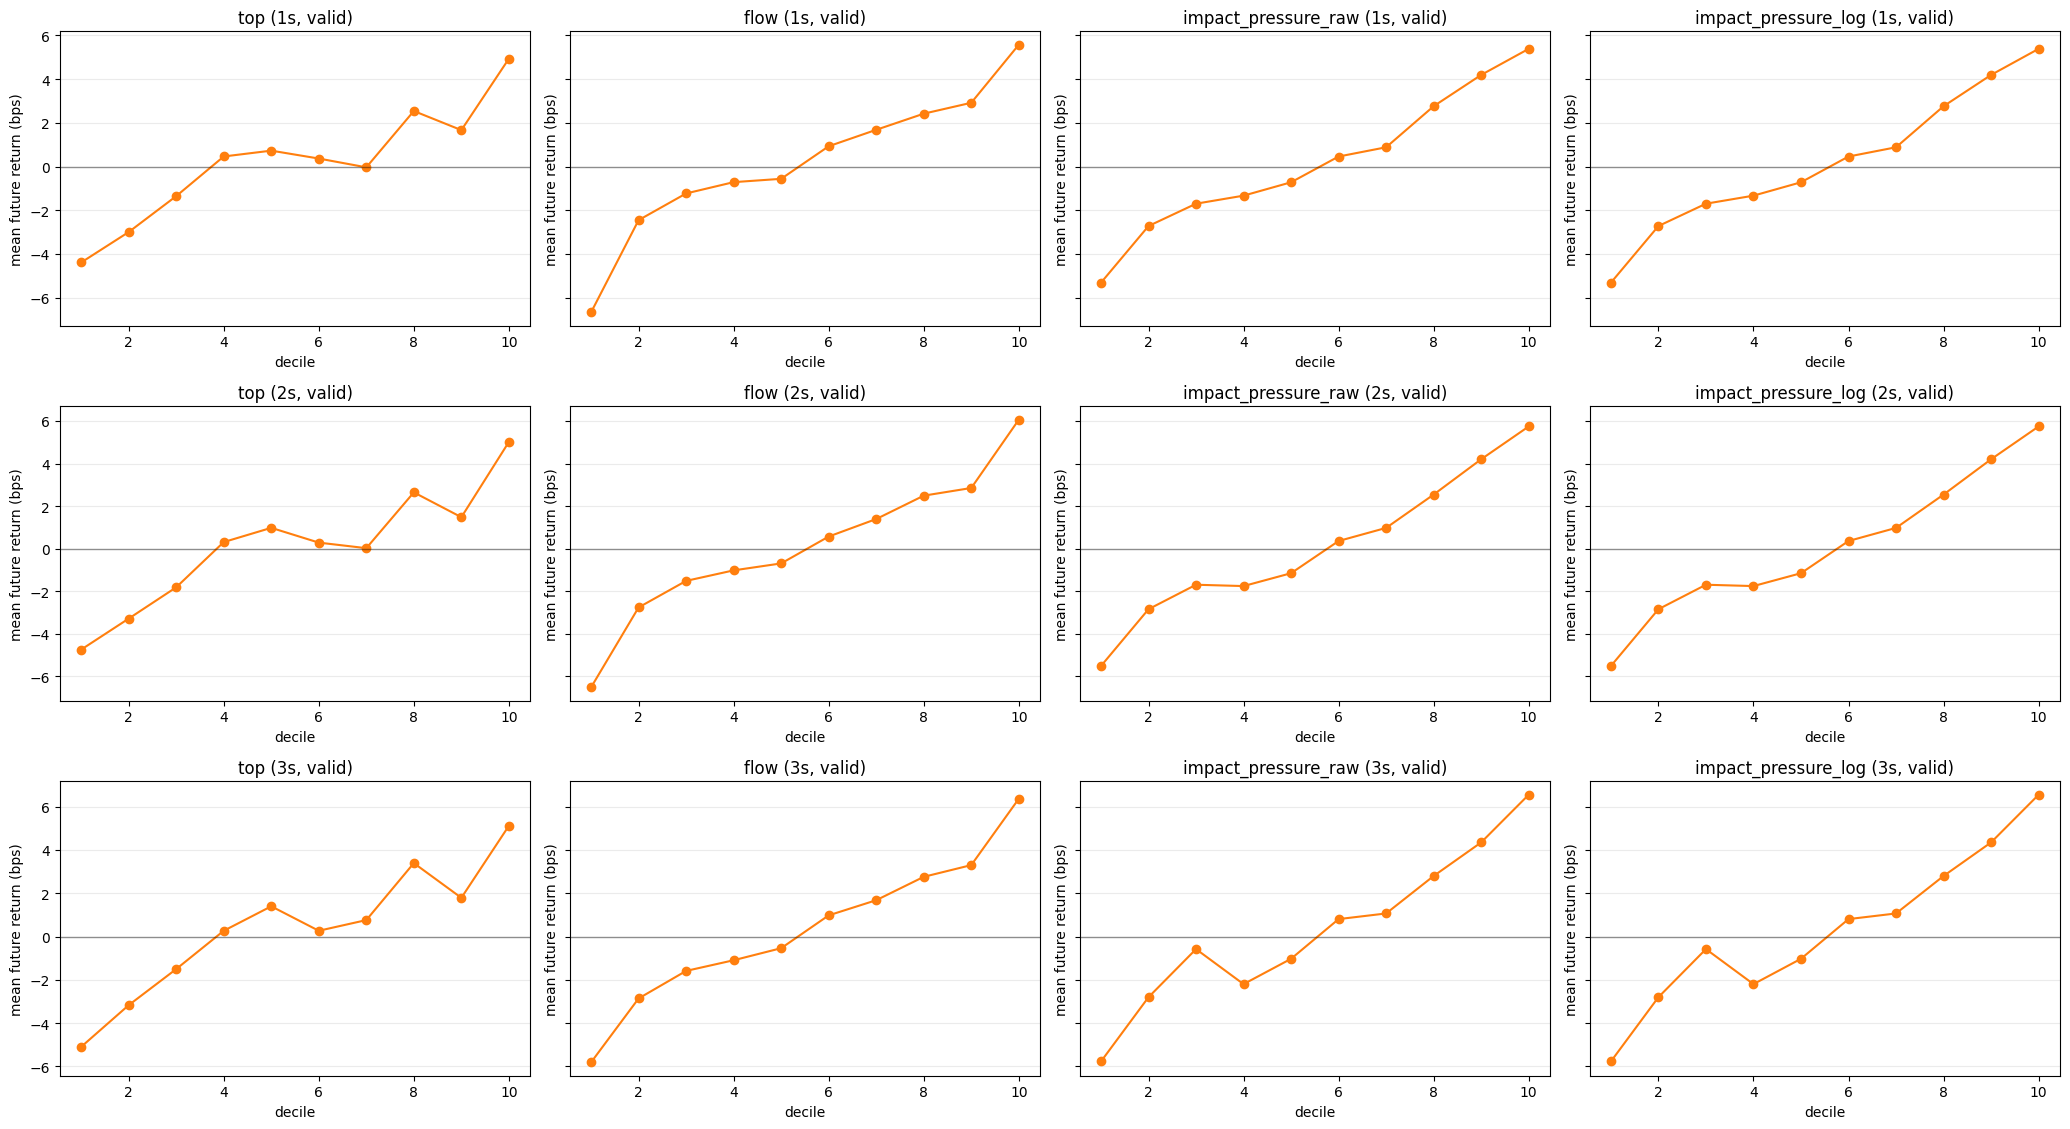

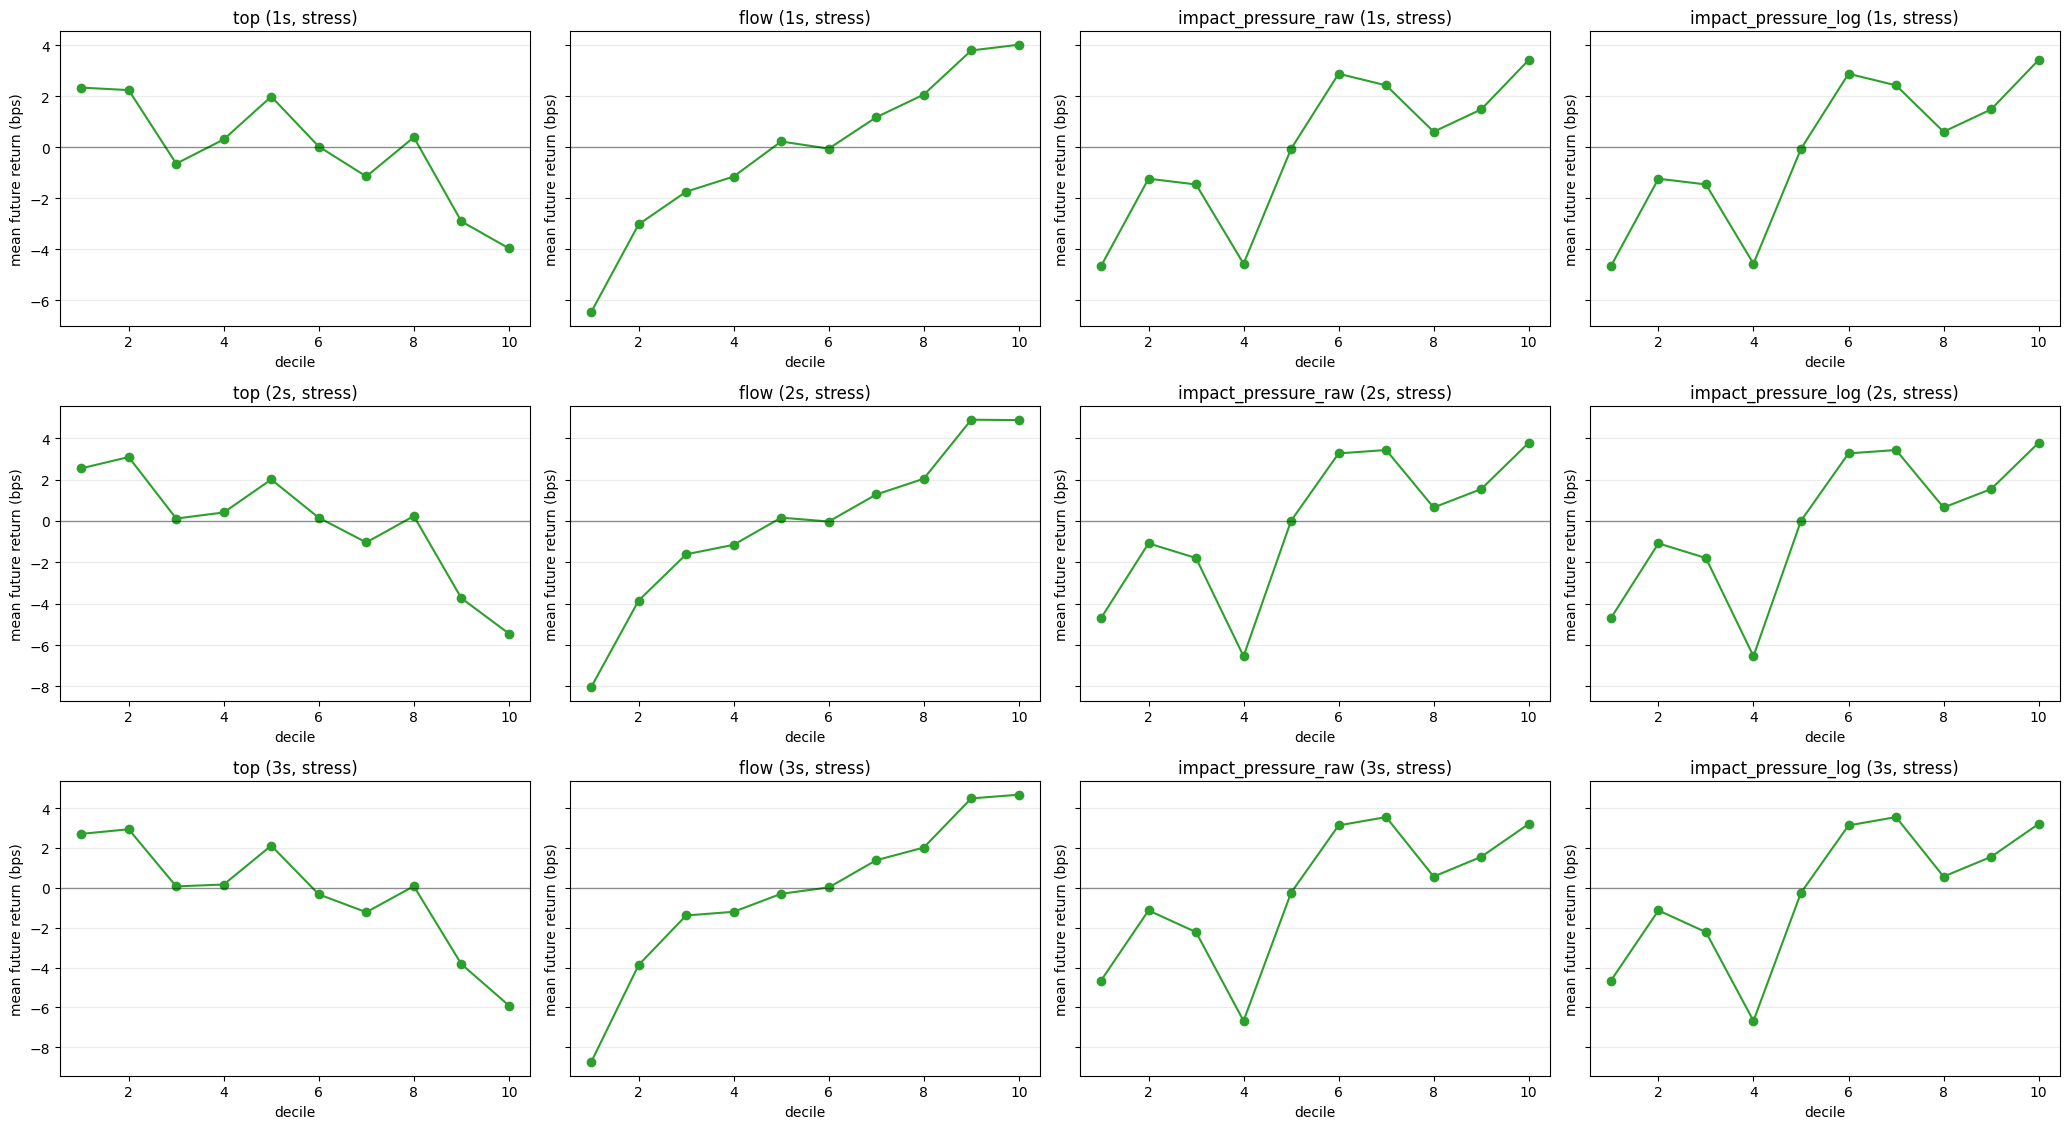

In [6]:
for split_name in ['valid', 'stress']:
    fig, axes = plt.subplots(len(HORIZONS), len(FEATURE_SPECS), figsize=(5.2 * len(FEATURE_SPECS), 3.8 * len(HORIZONS)), sharey='row')
    if len(HORIZONS) == 1:
        axes = np.array([axes])
    frame_color = 'C1' if split_name == 'valid' else 'C2'
    for row_idx, horizon in enumerate(HORIZONS):
        frame = get_split_frame(day_records, horizon, split_name)
        for col_idx, (feature_col, feature_name) in enumerate(FEATURE_SPECS):
            ax = axes[row_idx, col_idx]
            sub = frame[[feature_col, 'future_return']].dropna().copy()
            if len(sub) == 0:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
                ax.set_axis_off()
                continue
            sub['bucket'] = pd.qcut(sub[feature_col].rank(method='first'), q=min(10, len(sub)), labels=False, duplicates='drop')
            grp = sub.groupby('bucket', as_index=False)['future_return'].mean().sort_values('bucket')
            grp['bucket'] = grp['bucket'] + 1
            ax.plot(grp['bucket'], grp['future_return'] * 1e4, '-o', color=frame_color)
            ax.axhline(0.0, color='black', linewidth=1, alpha=0.4)
            ax.set_title(f'{feature_name} ({horizon}, {split_name})')
            ax.set_xlabel('decile')
            ax.set_ylabel('mean future return (bps)')
            ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

## Validation Scatter

A simple scatter is enough here. The x-axis is clipped to the 1st to 99th percentile for readability.


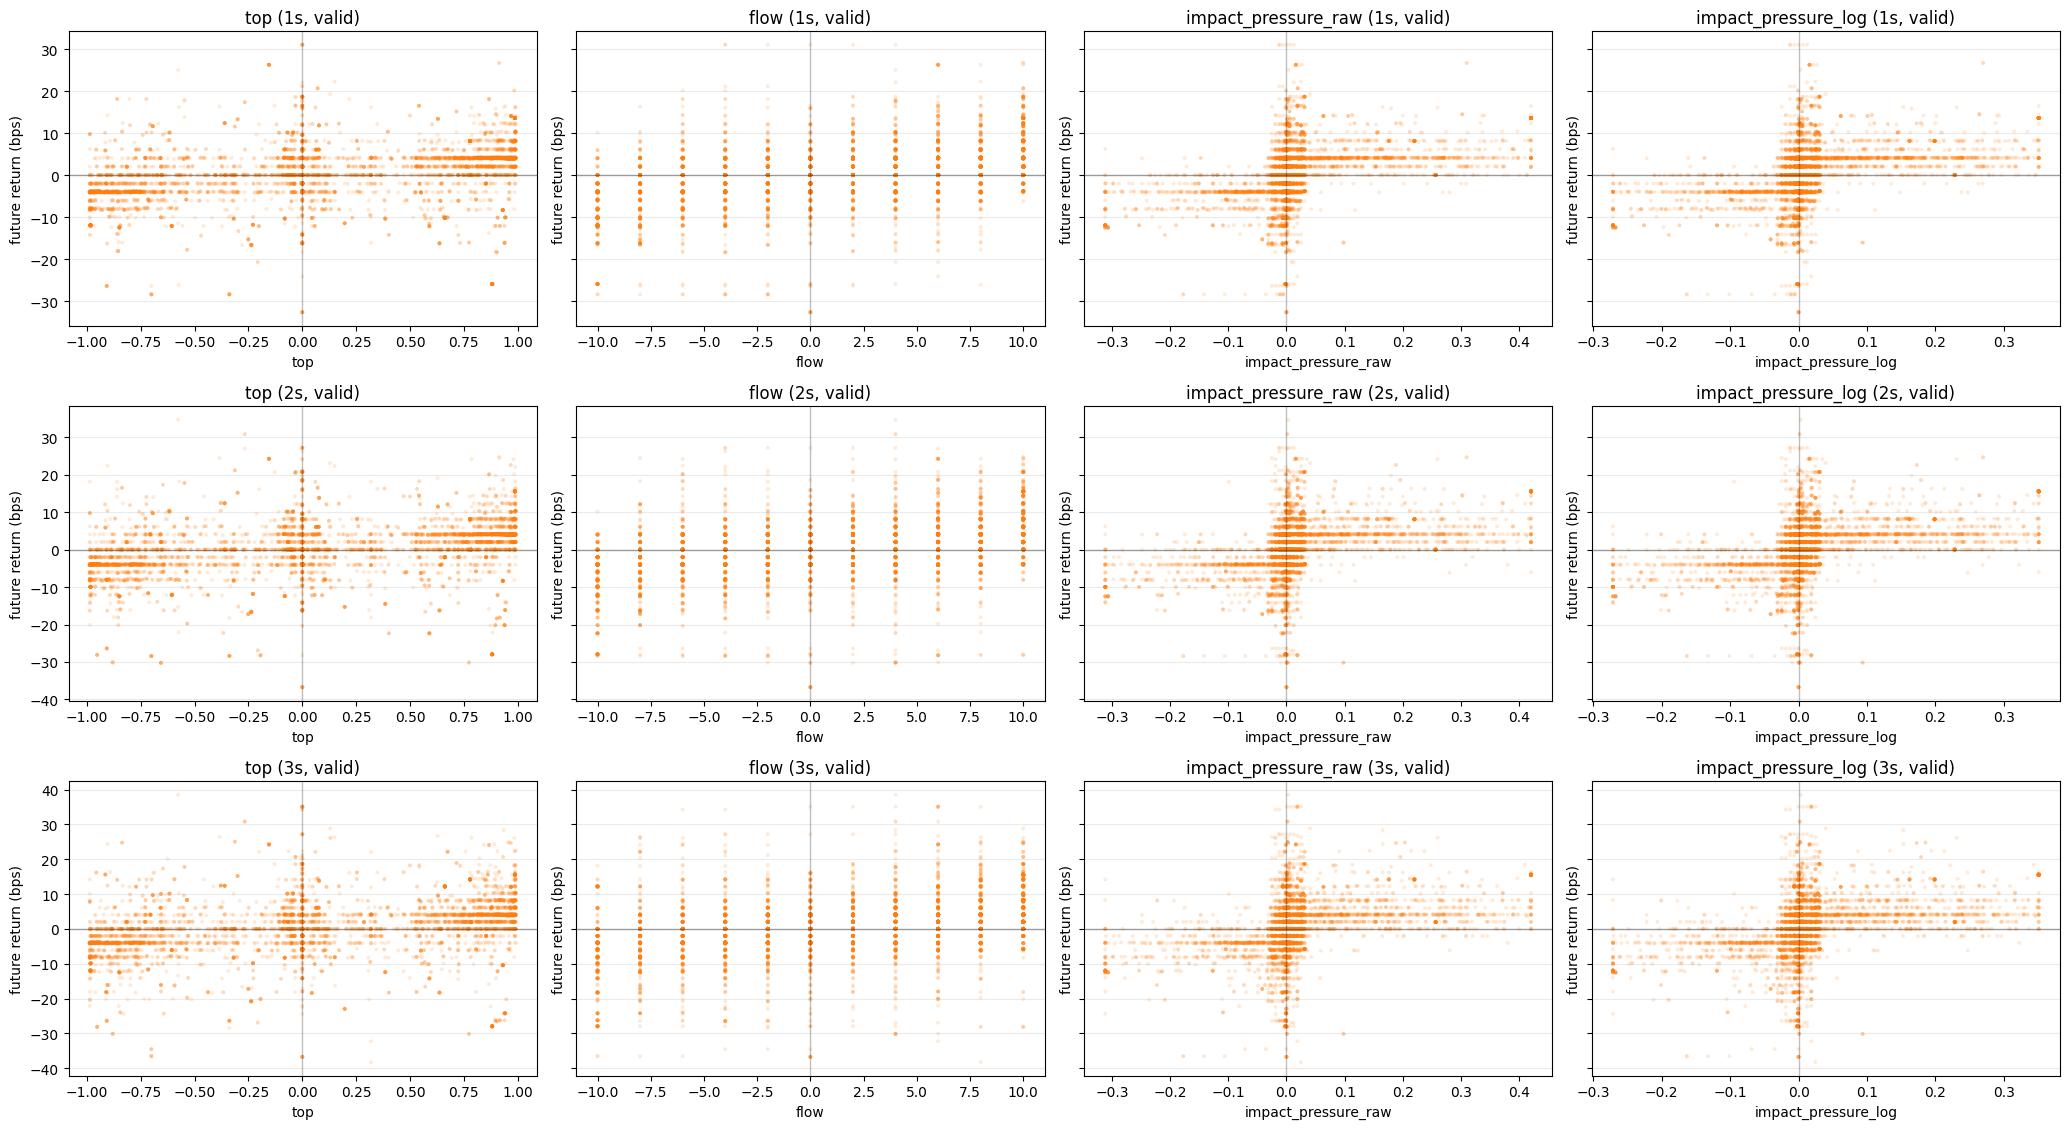

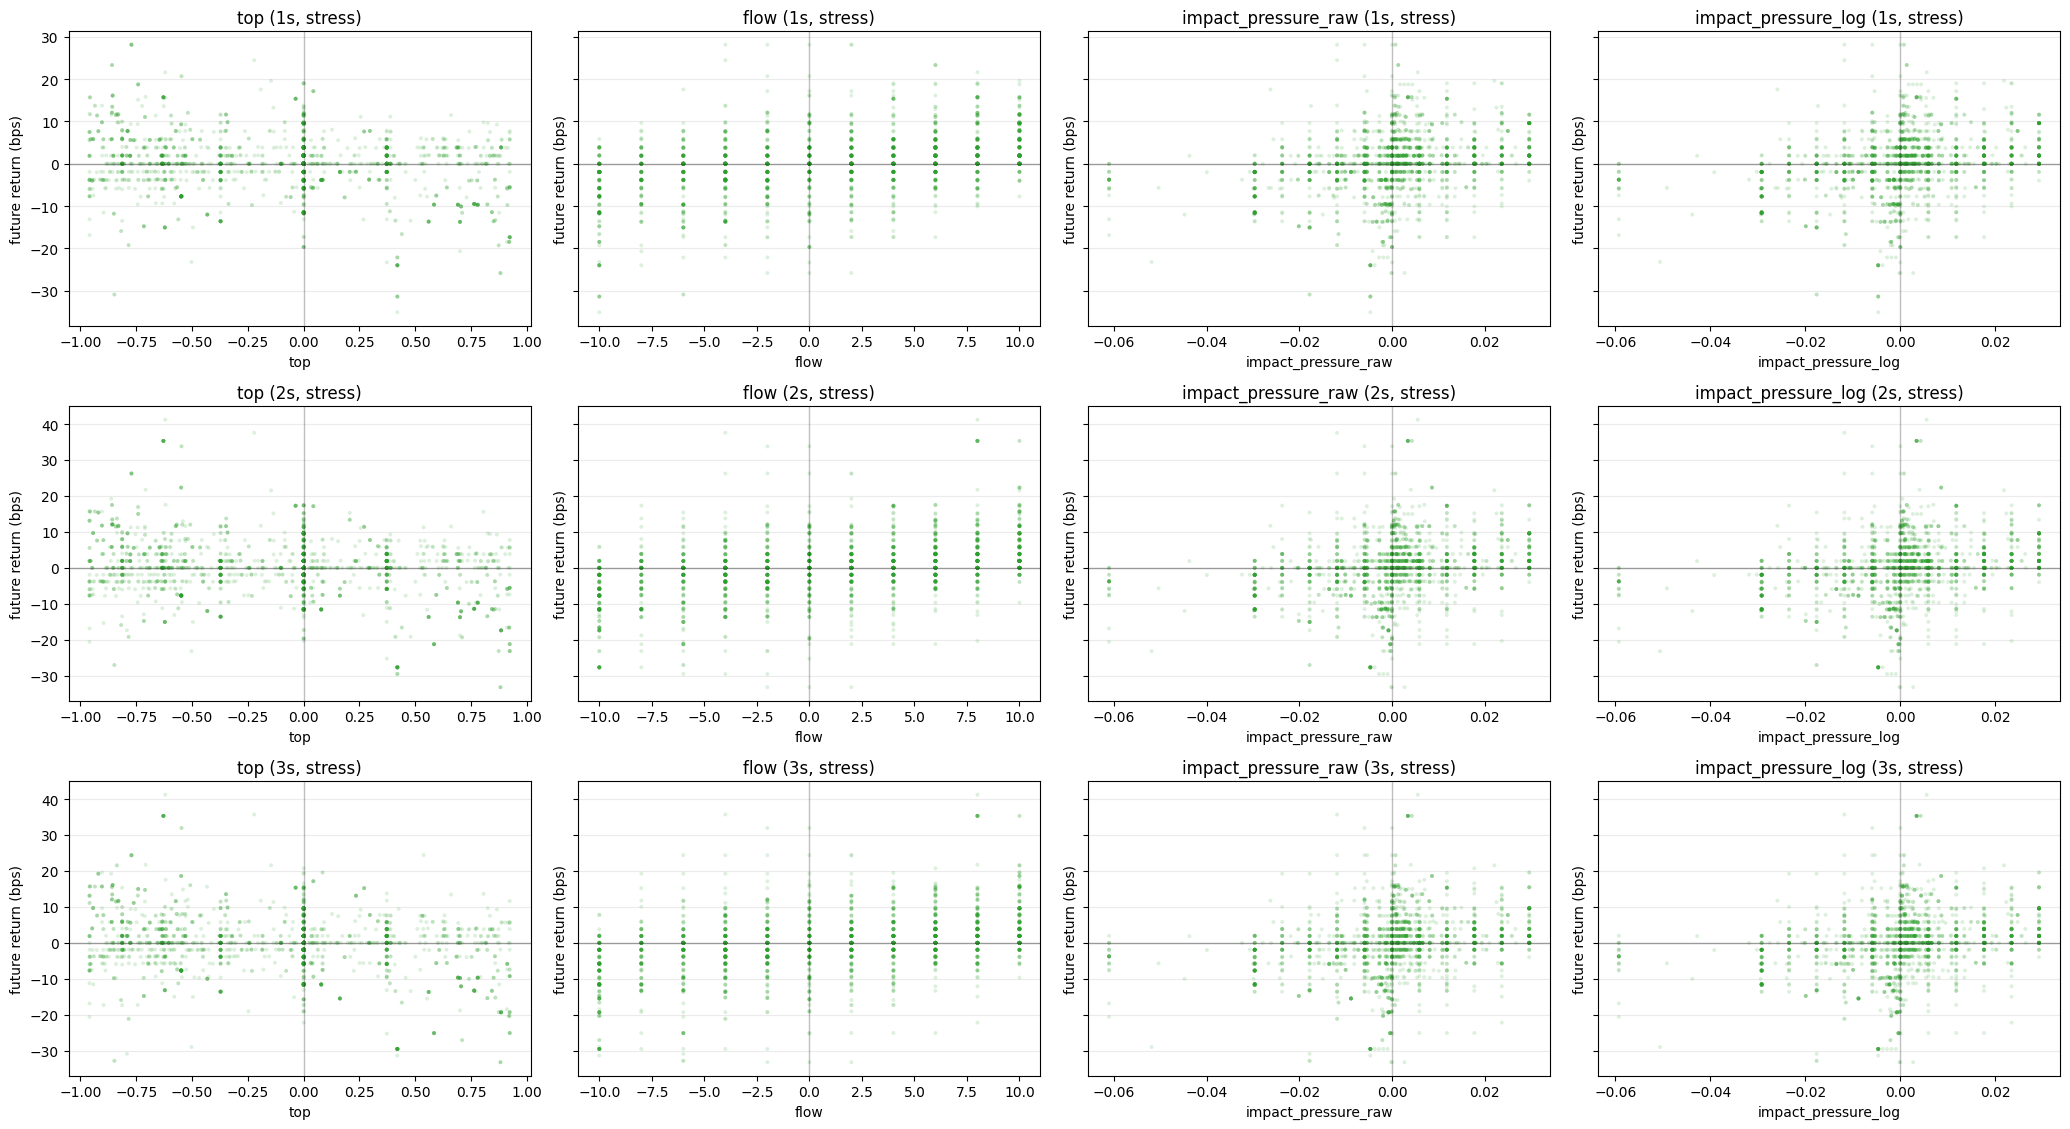

In [7]:
for split_name in ['valid', 'stress']:
    fig, axes = plt.subplots(len(HORIZONS), len(FEATURE_SPECS), figsize=(5.2 * len(FEATURE_SPECS), 3.8 * len(HORIZONS)), sharey='row')
    if len(HORIZONS) == 1:
        axes = np.array([axes])
    frame_color = 'C1' if split_name == 'valid' else 'C2'
    for row_idx, horizon in enumerate(HORIZONS):
        frame = get_split_frame(day_records, horizon, split_name)
        for col_idx, (feature_col, feature_name) in enumerate(FEATURE_SPECS):
            ax = axes[row_idx, col_idx]
            sub = frame[[feature_col, 'future_return']].dropna().copy()
            if len(sub) == 0:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
                ax.set_axis_off()
                continue
            x = sub[feature_col].to_numpy(dtype=float)
            y = sub['future_return'].to_numpy(dtype=float) * 1e4
            x_lo, x_hi = np.nanpercentile(x, [1, 99])
            if not np.isfinite(x_lo) or not np.isfinite(x_hi) or x_lo == x_hi:
                x_lo = float(np.nanmin(x))
                x_hi = float(np.nanmax(x))
                if x_lo == x_hi:
                    x_lo -= 1.0
                    x_hi += 1.0
            x_plot = np.clip(x, x_lo, x_hi)
            ax.scatter(x_plot, y, s=8, alpha=0.16, color=frame_color, edgecolors='none', rasterized=True)
            ax.axhline(0.0, color='black', linewidth=1, alpha=0.35)
            ax.axvline(0.0, color='black', linewidth=1, alpha=0.25)
            ax.set_title(f'{feature_name} ({horizon}, {split_name})')
            ax.set_xlabel(feature_name)
            ax.set_ylabel('future return (bps)')
            ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

## Univariate OLS

Each feature is fit on the train days and then evaluated on train, validation, and stress.


In [8]:
ols_rows = []
for horizon in HORIZONS:
    train = get_split_frame(day_records, horizon, 'train')
    valid = get_split_frame(day_records, horizon, 'valid')
    stress = get_split_frame(day_records, horizon, 'stress')
    for feature_col, feature_name in FEATURE_SPECS:
        beta = fit_ols_beta(train, [feature_col])
        for split_name, base in [('train', train), ('valid', valid), ('stress', stress)]:
            eval_frame, pred = ols_predict(base, [feature_col], beta)
            metrics = ols_metrics(eval_frame['future_return'].to_numpy(dtype=float), pred)
            ols_rows.append({
                'horizon': horizon,
                'feature': feature_name,
                'split': split_name,
                **metrics,
            })

ols_summary = pd.DataFrame(ols_rows).sort_values(['horizon', 'split', 'feature']).reset_index(drop=True)
display(ols_summary.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'hit_rate': '{:.6f}',
}))

,horizon,feature,split,n,r2,pearson,spearman,hit_rate
0,1s,flow,stress,2110,0.170071,0.418121,0.440517,0.534123
1,1s,impact_pressure_log,stress,2110,-0.027734,0.050185,0.351087,0.445024
2,1s,impact_pressure_raw,stress,2110,-0.004688,-0.001176,0.351087,0.366351
3,1s,top,stress,2119,-0.147365,-0.228367,-0.161002,0.347806
4,1s,flow,train,13141,0.200018,0.447233,0.479686,0.605814
5,1s,impact_pressure_log,train,13141,0.092546,0.304214,0.524457,0.617000
6,1s,impact_pressure_raw,train,13141,0.002695,0.051914,0.524457,0.451716
7,1s,top,train,13159,0.121758,0.348939,0.506150,0.636523
8,1s,flow,valid,5717,0.198337,0.451850,0.478372,0.584572
9,1s,impact_pressure_log,valid,5717,0.114520,0.346645,0.520646,0.588945


## Univariate Logistic

The target is `future_return > 0`. Zero returns stay in the sample and count as the non-positive class.


In [9]:
logit_rows = []
for horizon in HORIZONS:
    train = get_split_frame(day_records, horizon, 'train')
    valid = get_split_frame(day_records, horizon, 'valid')
    stress = get_split_frame(day_records, horizon, 'stress')
    for feature_col, feature_name in FEATURE_SPECS:
        fit = fit_logit(train, [feature_col])
        for split_name, base in [('train', train), ('valid', valid), ('stress', stress)]:
            eval_frame, y_true, prob = logit_predict(base, [feature_col], fit)
            metrics = binary_metrics(y_true, prob)
            logit_rows.append({
                'horizon': horizon,
                'feature': feature_name,
                'split': split_name,
                **metrics,
            })

logit_summary = pd.DataFrame(logit_rows).sort_values(['horizon', 'split', 'feature']).reset_index(drop=True)
display(logit_summary.style.format({
    'pos_rate': '{:.4f}',
    'pred_pos_rate': '{:.4f}',
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'specificity': '{:.4f}',
    'auc': '{:.4f}',
    'brier': '{:.6f}',
    'log_loss': '{:.6f}',
}))

,horizon,feature,split,n,pos_rate,pred_pos_rate,accuracy,precision,recall,specificity,auc,brier,log_loss,tp,tn,fp,fn
0,1s,flow,stress,2110,0.4071,0.4114,0.6573,0.5783,0.5844,0.7074,0.7025,0.215632,0.619745,502,885,366,357
1,1s,impact_pressure_log,stress,2110,0.4071,0.0976,0.6223,0.6505,0.1560,0.9424,0.6667,0.226386,0.668102,134,1179,72,725
2,1s,impact_pressure_raw,stress,2110,0.4071,0.0493,0.6156,0.7308,0.0885,0.9776,0.6667,0.228825,0.672968,76,1223,28,783
3,1s,top,stress,2119,0.4054,0.2294,0.5418,0.3848,0.2177,0.7627,0.4514,0.292837,0.817042,187,961,299,672
4,1s,flow,train,13141,0.3940,0.3335,0.7038,0.6467,0.5473,0.8056,0.7587,0.193265,0.567738,2834,6415,1548,2344
5,1s,impact_pressure_log,train,13141,0.3940,0.2138,0.7455,0.8263,0.4482,0.9387,0.8013,0.170619,0.515569,2321,7475,488,2857
6,1s,impact_pressure_raw,train,13141,0.3940,0.1756,0.7361,0.8705,0.3880,0.9625,0.8013,0.174102,0.522477,2009,7664,299,3169
7,1s,top,train,13159,0.3942,0.3490,0.7558,0.7149,0.6329,0.8358,0.8072,0.170619,0.516301,3283,6663,1309,1904
8,1s,flow,valid,5717,0.4516,0.4352,0.6659,0.6350,0.6119,0.7104,0.7283,0.209874,0.605989,1580,2227,908,1002
9,1s,impact_pressure_log,valid,5717,0.4516,0.2736,0.7156,0.8056,0.4880,0.9030,0.7700,0.187447,0.574994,1260,2831,304,1322


## Combined Models

This is the minimal check for whether `impact` still adds anything once `flow` and `top` are already present.


In [10]:
combined_ols_rows = []
combined_logit_rows = []

for horizon in HORIZONS:
    train = get_split_frame(day_records, horizon, 'train')
    valid = get_split_frame(day_records, horizon, 'valid')
    stress = get_split_frame(day_records, horizon, 'stress')

    for model_name, features in COMBINED_SPECS:
        beta = fit_ols_beta(train, features)
        fit = fit_logit(train, features)
        for split_name, base in [('train', train), ('valid', valid), ('stress', stress)]:
            eval_frame, pred = ols_predict(base, features, beta)
            metrics = ols_metrics(eval_frame['future_return'].to_numpy(dtype=float), pred)
            combined_ols_rows.append({
                'horizon': horizon,
                'model': model_name,
                'split': split_name,
                **metrics,
            })

            eval_frame_logit, y_true, prob = logit_predict(base, features, fit)
            metrics_logit = binary_metrics(y_true, prob)
            combined_logit_rows.append({
                'horizon': horizon,
                'model': model_name,
                'split': split_name,
                **metrics_logit,
            })

combined_ols_summary = pd.DataFrame(combined_ols_rows).sort_values(['horizon', 'split', 'model']).reset_index(drop=True)
combined_logit_summary = pd.DataFrame(combined_logit_rows).sort_values(['horizon', 'split', 'model']).reset_index(drop=True)

print('### Combined OLS')
display(combined_ols_summary.style.format({
    'r2': '{:.6f}',
    'pearson': '{:.6f}',
    'spearman': '{:.6f}',
    'hit_rate': '{:.6f}',
}))

print('### Combined Logistic')
display(combined_logit_summary.style.format({
    'pos_rate': '{:.4f}',
    'pred_pos_rate': '{:.4f}',
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'specificity': '{:.4f}',
    'auc': '{:.4f}',
    'brier': '{:.6f}',
    'log_loss': '{:.6f}',
}))

### Combined OLS


,horizon,model,split,n,r2,pearson,spearman,hit_rate
0,1s,flow+impact_pressure_log,stress,2110,0.159989,0.407011,0.434488,0.534123
1,1s,flow+impact_pressure_raw,stress,2110,0.169391,0.417252,0.434668,0.534123
2,1s,flow+top,stress,2110,0.091479,0.304030,0.353820,0.523697
3,1s,flow+top+impact_pressure_log,stress,2110,0.088709,0.301191,0.352921,0.524645
4,1s,flow+top+impact_pressure_raw,stress,2110,0.091657,0.304299,0.354241,0.524171
5,1s,top+impact_pressure_log,stress,2110,-0.111997,-0.143866,-0.095822,0.394313
6,1s,top+impact_pressure_raw,stress,2110,-0.149732,-0.231409,-0.126566,0.345498
7,1s,flow+impact_pressure_log,train,13141,0.205734,0.453579,0.504693,0.605814
8,1s,flow+impact_pressure_raw,train,13141,0.200164,0.447397,0.502696,0.605814
9,1s,flow+top,train,13141,0.266686,0.516417,0.626847,0.696446


### Combined Logistic


,horizon,model,split,n,pos_rate,pred_pos_rate,accuracy,precision,recall,specificity,auc,brier,log_loss,tp,tn,fp,fn
0,1s,flow+impact_pressure_log,stress,2110,0.4071,0.2346,0.6512,0.6242,0.3597,0.8513,0.6934,0.217371,0.646512,309,1065,186,550
1,1s,flow+impact_pressure_raw,stress,2110,0.4071,0.3199,0.6673,0.6163,0.4843,0.7930,0.6989,0.214702,0.641639,416,992,259,443
2,1s,flow+top,stress,2110,0.4071,0.3104,0.6028,0.5160,0.3935,0.7466,0.6287,0.245016,0.695907,338,934,317,521
3,1s,flow+top+impact_pressure_log,stress,2110,0.4071,0.3104,0.6028,0.5160,0.3935,0.7466,0.6288,0.245030,0.695905,338,934,317,521
4,1s,flow+top+impact_pressure_raw,stress,2110,0.4071,0.3104,0.6028,0.5160,0.3935,0.7466,0.6288,0.244962,0.695639,338,934,317,521
5,1s,top+impact_pressure_log,stress,2110,0.4071,0.1701,0.5744,0.4457,0.1863,0.8409,0.5110,0.261937,0.749307,160,1052,199,699
6,1s,top+impact_pressure_raw,stress,2110,0.4071,0.1867,0.5588,0.4086,0.1874,0.8137,0.4902,0.270324,0.772276,161,1018,233,698
7,1s,flow+impact_pressure_log,train,13141,0.3940,0.2749,0.7512,0.7641,0.5330,0.8930,0.8079,0.170408,0.512435,2760,7111,852,2418
8,1s,flow+impact_pressure_raw,train,13141,0.3940,0.2986,0.7369,0.7192,0.5450,0.8616,0.8037,0.173904,0.519300,2822,6861,1102,2356
9,1s,flow+top,train,13141,0.3940,0.3743,0.7970,0.7552,0.7175,0.8488,0.8719,0.140837,0.437588,3715,6759,1204,1463


## Conclusion

This notebook is the simple baseline for the `04` work.
Read it as the answer to three questions:

1. which single feature is strongest on the same rows?
2. does the log transform improve raw impact?
3. does impact still add anything once `flow` and `top` are already in the model?

The practical conclusion is that `flow` and `top` are the core short-horizon features, `impact_pressure_log` is cleaner than raw impact, and any impact-based extension should be judged relative to the `flow + top` baseline rather than on its own.